In [ ]:
import pandas as pd
import numpy as np
import joblib, json, pathlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({'figure.facecolor': '#22272E', 'axes.facecolor': '#22272E', 'text.color': 'white', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white', 'axes.edgecolor': '#22272E', 'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False, 'axes.spines.bottom': False, 'grid.color': '#32373E'})
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 150)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

ENCDM = pd.read_parquet('../Data/Processed/CleanENCDM.parquet')
RGPH = pd.read_parquet('../Data/Processed/CleanRGPH.parquet')

Colors = {'orange' : '#F4583E', 'blue' : '#62C1FE', 'purple' : '#8957E5', 'green' : '#2EA043', 'grey' : '#444C56', 'gold' : '#D29922', 'pink' : '#F92672'}

with open('../Assets/Maps/MapENCDM.json', 'r', encoding = 'utf-8') as file :
    MapENCDM = json.load(file)
    MapENCDM = {column : {code : label for label, code in values.items() if code is not None} for column, values in MapENCDM.items()}
with open('../Assets/Maps/MapRGPH.json', 'r', encoding = 'utf-8') as file :
    MapRGPH = json.load(file)
    MapRGPH = {column : {code : label for label, code in values.items() if code is not None} for column, values in MapRGPH.items()}

for scaler in [file.name for file in pathlib.Path('../Models/Scalers/ENCDM/').glob('*')] :
    ENCDM[scaler.removeprefix('SS_').removesuffix('.joblib')] = joblib.load(f'../Models/Scalers/ENCDM/{scaler}').inverse_transform(pd.DataFrame(ENCDM[scaler.removeprefix('SS_').removesuffix('.joblib')]))
for scaler in [file.name for file in pathlib.Path('../Models/Scalers/RGPH/').glob('*')] :
    RGPH[scaler.removeprefix('SS_').removesuffix('.joblib')] = joblib.load(f'../Models/Scalers/RGPH/{scaler}').inverse_transform(pd.DataFrame(RGPH[scaler.removeprefix('SS_').removesuffix('.joblib')]))

display(ENCDM.head(5), RGPH.head(5))

,N_ménage,coef_ménage,coef_indiv,Milieu,Région_12,Taille_ménage,Taille_agregée,Pauvre,Vulnérable,Quintiles,Deciles,Quintileurbain,Decileurbain,Quintilerural,Decilerural,Sexe_CM,Age_CM,Age_quin_CM,Lieunaissance_CM,Etat_matrimonial_CM,Niveau_scolaire_agreg_CM,Diplôme_agregé_CM,Type_activité_dominante_CM,Profession_agreg_CM,Secteur_activité_agreg_CM,Situation_profession_agreg_CM
0,1.0,165.0,560.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,165.0,676.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,36.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
2,3.0,165.0,677.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,2.0,2.0,2.0,1.0,1.0,0.0,38.0,1.0,2.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0
3,4.0,165.0,796.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,34.0,2.0,1.0,0.0,2.0,2.0,0.0,3.0,3.0,1.0
4,5.0,165.0,789.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,42.0,3.0,2.0,0.0,2.0,2.0,0.0,1.0,4.0,1.0


,REG,PRO,MIL,MEN.PRO,TAILLE,TYPE.LOG,MURS,TOIT,SOL,AGE.LOG,PIECES,STAT.OCC,CUIS,WC,BD,BLOC,ECL.MODE,EAU.MODE,EAU.DIST,EAU.DUR,EAUX.US,DECH,GAZ,ELEC,CHAR,BOIS,DEJ.ANIM,TELE,RADIO,TEL.PORT,TEL.FIXE,NET,PC,PARAB,FRIGO,CAM,VOIT,TRACT,MOTO,ROUTE.DIST,MEN.TYPE,PDS
0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.11699,0.0,9.999995
1,0.0,0.0,1.0,2.0,5.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00000,1.0,9.999995
2,0.0,0.0,1.0,3.0,5.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.00000,2.0,9.999995
3,0.0,0.0,1.0,4.0,7.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,2.0,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.00000,3.0,9.999995
4,0.0,0.0,1.0,5.0,5.0,2.0,2.0,2.0,0.0,3.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.00000,2.0,9.999995


In [19]:
RegionBridge = {e : next(r for r, name in MapRGPH['REG'].items() if name == MapENCDM['Région_12'][e]) for e in MapENCDM['Région_12']}
RegionBridgeInv = {r : e for e, r in RegionBridge.items()}

GUELMIM = {'ENCDM': 2, 'RGPH': 9, 'PRO': 66}

ENCDMConfig = {
    'categorical': ['Milieu', 'Région_12', 'Taille_agregée', 'Sexe_CM', 'Niveau_scolaire_agreg_CM', 'Situation_profession_agreg_CM'],
    'numerical': ['Taille_ménage', 'Age_CM'],
    'target': ['Pauvre', 'Vulnérable'],
    'weight': 'coef_indiv'
}

RGPHConfig = {
    'categorical': ['REG', 'MIL', 'TYPE.LOG', 'MURS', 'TOIT', 'SOL', 'EAU.MODE', 'ELEC', 'NET', 'VOIT'],
    'numerical': ['TAILLE', 'PIECES', 'ROUTE.DIST'],
    'weight': 'PDS'
}

EmbENCDM = {c : len(MapENCDM[c]) for c in ENCDMConfig['categorical']}
EmbRGPH = {c : len(MapRGPH[c]) for c in RGPHConfig['categorical']}

display(
    pd.DataFrame({'ENCDM': [MapENCDM['Région_12'][c] for c in sorted(RegionBridge)], 'RGPH': [MapRGPH['REG'][RegionBridge[c]] for c in sorted(RegionBridge)]}, index = sorted(RegionBridge)).T,
    pd.DataFrame({'ENCDM': EmbENCDM, 'RGPH': EmbRGPH}).T
)

,0,1,2,3,4,5,6,7,8,9,10,11
ENCDM,Dakhla-Oued Ed Dahab,Laâyoune-Sakia El Hamra,Guelmim-Oued Noun,Souss-Massa,Drâa-Tafilalet,Rabat-Salé-Kénitra,Casablanca-Settat,Béni Mellal-Khénifra,Marrakech-Safi,Oriental,Fès-Meknès,Tanger-Tétouan-Al Hoceïma
RGPH,Dakhla-Oued Ed Dahab,Laâyoune-Sakia El Hamra,Guelmim-Oued Noun,Souss-Massa,Drâa-Tafilalet,Rabat-Salé-Kénitra,Casablanca-Settat,Béni Mellal-Khénifra,Marrakech-Safi,Oriental,Fès-Meknès,Tanger-Tétouan-Al Hoceïma


,Milieu,Région_12,Taille_agregée,Sexe_CM,Niveau_scolaire_agreg_CM,Situation_profession_agreg_CM,REG,MIL,TYPE.LOG,MURS,TOIT,SOL,EAU.MODE,ELEC,NET,VOIT
ENCDM,2.0,12.0,6.0,2.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RGPH,NaN,NaN,NaN,NaN,NaN,NaN,12.0,2.0,6.0,7.0,6.0,5.0,7.0,3.0,2.0,3.0


In [20]:
ENCDM['REG_RGPH'] = ENCDM['Région_12'].map(RegionBridge)
ENCDM['poor_w'] = ENCDM['Pauvre'] * ENCDM['coef_indiv']
ENCDM['vuln_w'] = ENCDM['Vulnérable'] * ENCDM['coef_indiv']

StrataENCDM = ENCDM.groupby(['REG_RGPH', 'Milieu']).agg(individuals = ('coef_indiv', 'sum'), poor = ('poor_w', 'sum'), vulnerable = ('vuln_w', 'sum')).reset_index()
StrataRGPH = RGPH.groupby(['REG', 'MIL']).agg(households = ('PDS', 'sum')).reset_index()

Strata = StrataENCDM.merge(StrataRGPH, left_on = ['REG_RGPH', 'Milieu'], right_on = ['REG', 'MIL'], how = 'inner')
Strata['poverty_rate'] = Strata['poor'] / Strata['individuals']
Strata['region'] = Strata['REG_RGPH'].map(MapRGPH['REG'])

display(Strata.sort_values('poverty_rate', ascending = False).head(10))

,REG_RGPH,Milieu,individuals,poor,vulnerable,REG,MIL,households,poverty_rate,region
15,7,1.0,1064526.0,219654.0,197565.0,7.0,1.0,158599.913260,0.206340,Drâa-Tafilalet
9,4,1.0,1301692.0,191723.0,291616.0,4.0,1.0,232339.872931,0.147288,Béni Mellal-Khénifra
5,2,1.0,1684969.0,177246.0,357825.0,2.0,1.0,318809.825639,0.105192,Fès-Meknès
3,1,1.0,828691.0,81868.0,92087.0,1.0,1.0,155589.914906,0.098792,Oriental
17,8,1.0,1180735.0,111533.0,292177.0,8.0,1.0,246899.864968,0.094461,Souss-Massa
13,6,1.0,2569820.0,222296.0,497630.0,6.0,1.0,482359.736192,0.086503,Marrakech-Safi
7,3,1.0,1388246.0,118752.0,328715.0,3.0,1.0,247509.864634,0.085541,Rabat-Salé-Kénitra
19,9,1.0,155647.0,10668.0,18379.0,9.0,1.0,28339.984501,0.068540,Guelmim-Oued Noun
18,9,0.0,275954.0,17184.0,39360.0,9.0,0.0,60999.966638,0.062271,Guelmim-Oued Noun
11,5,1.0,1829730.0,79556.0,296076.0,5.0,1.0,344329.811682,0.043480,Casablanca-Settat


In [21]:
from sklearn.model_selection import train_test_split

Features = ENCDMConfig['categorical'] + ENCDMConfig['numerical']
Targets = ENCDMConfig['target']
WeightCol = ENCDMConfig['weight']

X = ENCDM[Features].astype('float32')
StrataKey = ENCDM['REG_RGPH'].astype(int).astype(str) + '_' + ENCDM['Milieu'].astype(int).astype(str)

Idx = np.arange(len(ENCDM))
TrainIdx, TempIdx = train_test_split(Idx, test_size = 0.3, stratify = StrataKey, random_state = 42)
ValIdx, TestIdx = train_test_split(TempIdx, test_size = 0.5, stratify = StrataKey.iloc[TempIdx], random_state = 42)

Splits = {'train': TrainIdx, 'val': ValIdx, 'test': TestIdx}
ScalePosWeight = {target : (ENCDM[target].iloc[TrainIdx] == 0).sum() / max(1, (ENCDM[target].iloc[TrainIdx] == 1).sum()) for target in Targets}

print({k: len(v) for k, v in Splits.items()})
print('ScalePosWeight:', ScalePosWeight)

{'train': 11179, 'val': 2395, 'test': 2396}
ScalePosWeight: {'Pauvre': np.float64(31.591836734693878), 'Vulnérable': np.float64(9.82187802516941)}


In [22]:
import warnings
warnings.filterwarnings('ignore', category = UserWarning, module = 'sklearn')
from lightgbm import LGBMClassifier as LGBMC

pathlib.Path('../Models/Classifier').mkdir(parents = True, exist_ok = True)

Models = {}
Thresholds = {}

for target in Targets :
    model = LGBMC(n_estimators = 400, max_depth = 7, learning_rate = 0.05, scale_pos_weight = ScalePosWeight[target], n_jobs = -1, verbose = -1)
    model.fit(X.iloc[TrainIdx], ENCDM[target].iloc[TrainIdx].astype(int), sample_weight = ENCDM[WeightCol].iloc[TrainIdx])
    Models[target] = model

    valprob = model.predict_proba(X.iloc[ValIdx])[:, 1]
    from sklearn.metrics import precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(ENCDM[target].iloc[ValIdx].astype(int), valprob, sample_weight = ENCDM[WeightCol].iloc[ValIdx])
    f1scores = 2 * precision * recall / (precision + recall + 1e-9)
    Thresholds[target] = thresholds[f1scores[:-1].argmax()] if len(thresholds) else 0.5

    if not pathlib.Path(f'../Models/Classifier/ENCDM_LGBM_{target}.joblib').exists() :
        joblib.dump({'model': model, 'features': Features, 'threshold': Thresholds[target]}, f'../Models/Classifier/ENCDM_LGBM_{target}.joblib')

display(pd.DataFrame({'threshold': Thresholds}))

,threshold
Pauvre,0.608335
Vulnérable,0.515145


In [23]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, precision_score, recall_score

def WeightedMetrics(ytrue, yprob, ypred, weights) :
    return {
        'AUC': roc_auc_score(ytrue, yprob, sample_weight = weights),
        'F1': f1_score(ytrue, ypred, sample_weight = weights),
        'Precision': precision_score(ytrue, ypred, sample_weight = weights, zero_division = 0),
        'Recall': recall_score(ytrue, ypred, sample_weight = weights, zero_division = 0)
    }

Metrics = {}
Confusions = {}

for splitname, splitidx in Splits.items() :
    Metrics[splitname] = {}
    Confusions[splitname] = {}
    for target in Targets :
        prob = Models[target].predict_proba(X.iloc[splitidx])[:, 1]
        pred = (prob >= Thresholds[target]).astype(int)
        ytrue = ENCDM[target].iloc[splitidx].astype(int)
        weights = ENCDM[WeightCol].iloc[splitidx]
        Metrics[splitname][target] = WeightedMetrics(ytrue, prob, pred, weights)
        Confusions[splitname][target] = confusion_matrix(ytrue, pred, sample_weight = weights)

MetricsTable = pd.DataFrame({(splitname, target): metrics for splitname, targets in Metrics.items() for target, metrics in targets.items()}).T
display(MetricsTable.round(4))

AUC      F1  Precision  Recall
train Pauvre      0.9884  0.5532     0.3845  0.9859
      Vulnérable  0.9262  0.4814     0.3238  0.9379
val   Pauvre      0.7648  0.2773     0.2002  0.4507
      Vulnérable  0.7102  0.3386     0.2337  0.6142
test  Pauvre      0.7810  0.2357     0.1677  0.3965
      Vulnérable  0.7423  0.3335     0.2277  0.6228

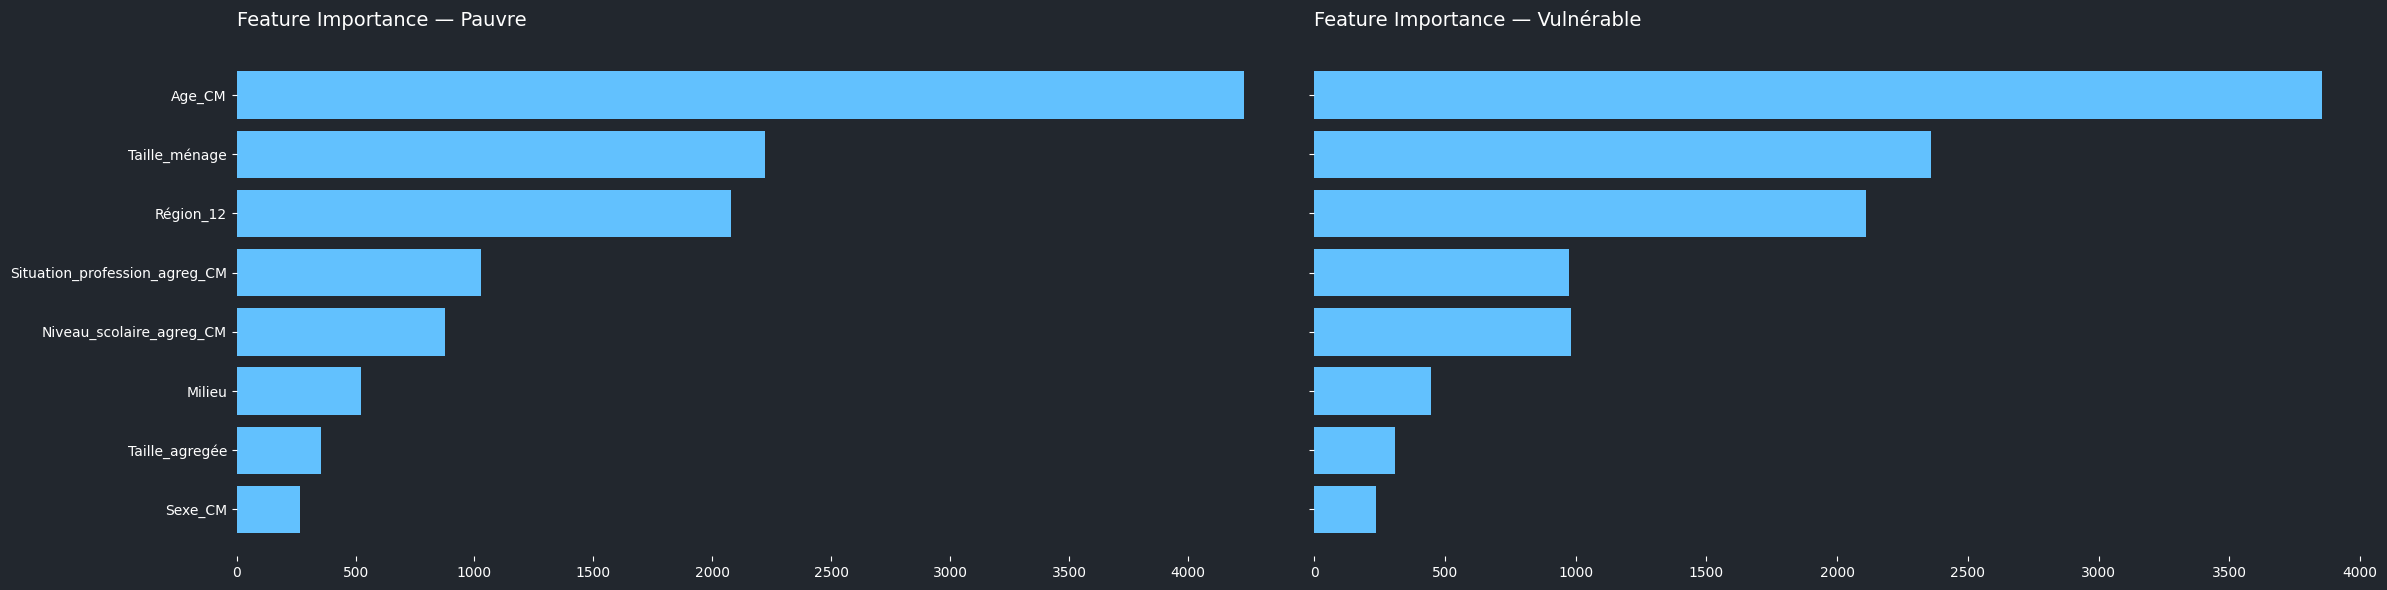

In [24]:
fig, axes = plt.subplots(1, len(Targets), figsize = (24, 6), sharey = True)
if len(Targets) == 1 : axes = [axes]

for ax, target in zip(axes, Targets) :
    importance = pd.Series(Models[target].feature_importances_, index = Features).sort_values()
    ax.barh(importance.index, importance.values, color = Colors['blue'])
    ax.set_title(f'Feature Importance — {target}', loc = 'left', fontsize = 14, pad = 16)
    for spine in ax.spines.values() : spine.set_visible(False)

plt.tight_layout()
plt.savefig('../Assets/Plots/Model Feature Importance.png', dpi = 150, facecolor = '#22272E', bbox_inches = 'tight')
plt.show()

In [25]:
SharedFeatures = ['Milieu', 'Région_12', 'Taille_ménage', 'Taille_agregée']
TailleMap = {1: 5, 2: 0, 3: 1, 4: 2, 5: 3}

RGPH['Région_12'] = RGPH['REG'].map(RegionBridgeInv)
RGPH['Taille_agregée'] = RGPH['TAILLE'].apply(lambda s: TailleMap.get(int(round(max(1, s))), 4))

XRgph = pd.DataFrame({'Milieu': RGPH['MIL'], 'Région_12': RGPH['Région_12'], 'Taille_ménage': RGPH['TAILLE'], 'Taille_agregée': RGPH['Taille_agregée']}).astype('float32')

from sklearn.isotonic import IsotonicRegression

TransferModels = {}
Calibrators = {}

for target in Targets :
    transfer = LGBMC(n_estimators = 300, max_depth = 6, learning_rate = 0.05, scale_pos_weight = ScalePosWeight[target], n_jobs = -1, verbose = -1)
    transfer.fit(ENCDM[SharedFeatures].astype('float32').iloc[TrainIdx], ENCDM[target].iloc[TrainIdx].astype(int), sample_weight = ENCDM[WeightCol].iloc[TrainIdx])
    TransferModels[target] = transfer

    valprob = transfer.predict_proba(ENCDM[SharedFeatures].astype('float32').iloc[ValIdx])[:, 1]
    calibrator = IsotonicRegression(out_of_bounds = 'clip')
    calibrator.fit(valprob, ENCDM[target].iloc[ValIdx].astype(int), sample_weight = ENCDM[WeightCol].iloc[ValIdx])
    Calibrators[target] = calibrator

    RGPH[f'pred_{target}'] = calibrator.transform(transfer.predict_proba(XRgph)[:, 1])
    joblib.dump({'model': transfer, 'calibrator': calibrator, 'features': SharedFeatures, 'threshold': Thresholds[target]}, f'../Models/Classifier/Transfer_LGBM_{target}.joblib')

TestEncdm = ENCDM.iloc[TestIdx].copy()
TestEncdm['pred_Pauvre_transfer'] = Calibrators['Pauvre'].transform(TransferModels['Pauvre'].predict_proba(TestEncdm[SharedFeatures].astype('float32'))[:, 1])
TestEncdm['pred_poor_w'] = TestEncdm['pred_Pauvre_transfer'] * TestEncdm['coef_indiv']

StrataCompare = TestEncdm.groupby(['REG_RGPH', 'Milieu']).agg(individuals = ('coef_indiv', 'sum'), observed_poor = ('poor_w', 'sum'), predicted_poor = ('pred_poor_w', 'sum')).reset_index()
StrataCompare['poverty_rate'] = StrataCompare['observed_poor'] / StrataCompare['individuals']
StrataCompare['predicted_rate'] = StrataCompare['predicted_poor'] / StrataCompare['individuals']
StrataCompare['rate_diff'] = StrataCompare['predicted_rate'] - StrataCompare['poverty_rate']
StrataCompare['region'] = StrataCompare['REG_RGPH'].map(MapRGPH['REG'])

RGPH['pred_poor_w'] = RGPH['pred_Pauvre'] * RGPH['PDS']
RgphStrataRate = RGPH.groupby(['REG', 'MIL']).agg(rgph_pred_rate = ('pred_poor_w', 'sum'), households = ('PDS', 'sum')).reset_index()
RgphStrataRate['rgph_pred_rate'] = RgphStrataRate['rgph_pred_rate'] / RgphStrataRate['households']

display(StrataCompare[['region', 'Milieu', 'poverty_rate', 'predicted_rate', 'rate_diff']].sort_values('rate_diff', key = abs, ascending = False).head(12))
display(RgphStrataRate.merge(Strata[['REG', 'MIL', 'poverty_rate', 'region']], on = ['REG', 'MIL'], how = 'left')[['region', 'MIL', 'poverty_rate', 'rgph_pred_rate']].head(8))

,region,Milieu,poverty_rate,predicted_rate,rate_diff
19,Guelmim-Oued Noun,1.0,0.185215,0.044715,-0.140501
18,Guelmim-Oued Noun,0.0,0.154759,0.081325,-0.073434
15,Drâa-Tafilalet,1.0,0.226565,0.154821,-0.071743
9,Béni Mellal-Khénifra,1.0,0.206848,0.138376,-0.068471
5,Fès-Meknès,1.0,0.067273,0.122210,0.054937
13,Marrakech-Safi,1.0,0.038015,0.081833,0.043818
8,Béni Mellal-Khénifra,0.0,0.011994,0.048225,0.036231
17,Souss-Massa,1.0,0.110382,0.074227,-0.036155
7,Rabat-Salé-Kénitra,1.0,0.052601,0.086278,0.033677
16,Souss-Massa,0.0,0.044117,0.019021,-0.025095


,region,MIL,poverty_rate,rgph_pred_rate
0,Tanger-Tétouan-Al Hoceïma,0.0,0.007428,0.007821
1,Tanger-Tétouan-Al Hoceïma,1.0,0.042814,0.029668
2,Oriental,0.0,0.028275,0.014492
3,Oriental,1.0,0.098792,0.073791
4,Fès-Meknès,0.0,0.015845,0.014989
5,Fès-Meknès,1.0,0.105192,0.080217
6,Rabat-Salé-Kénitra,0.0,0.016632,0.014546
7,Rabat-Salé-Kénitra,1.0,0.085541,0.070502


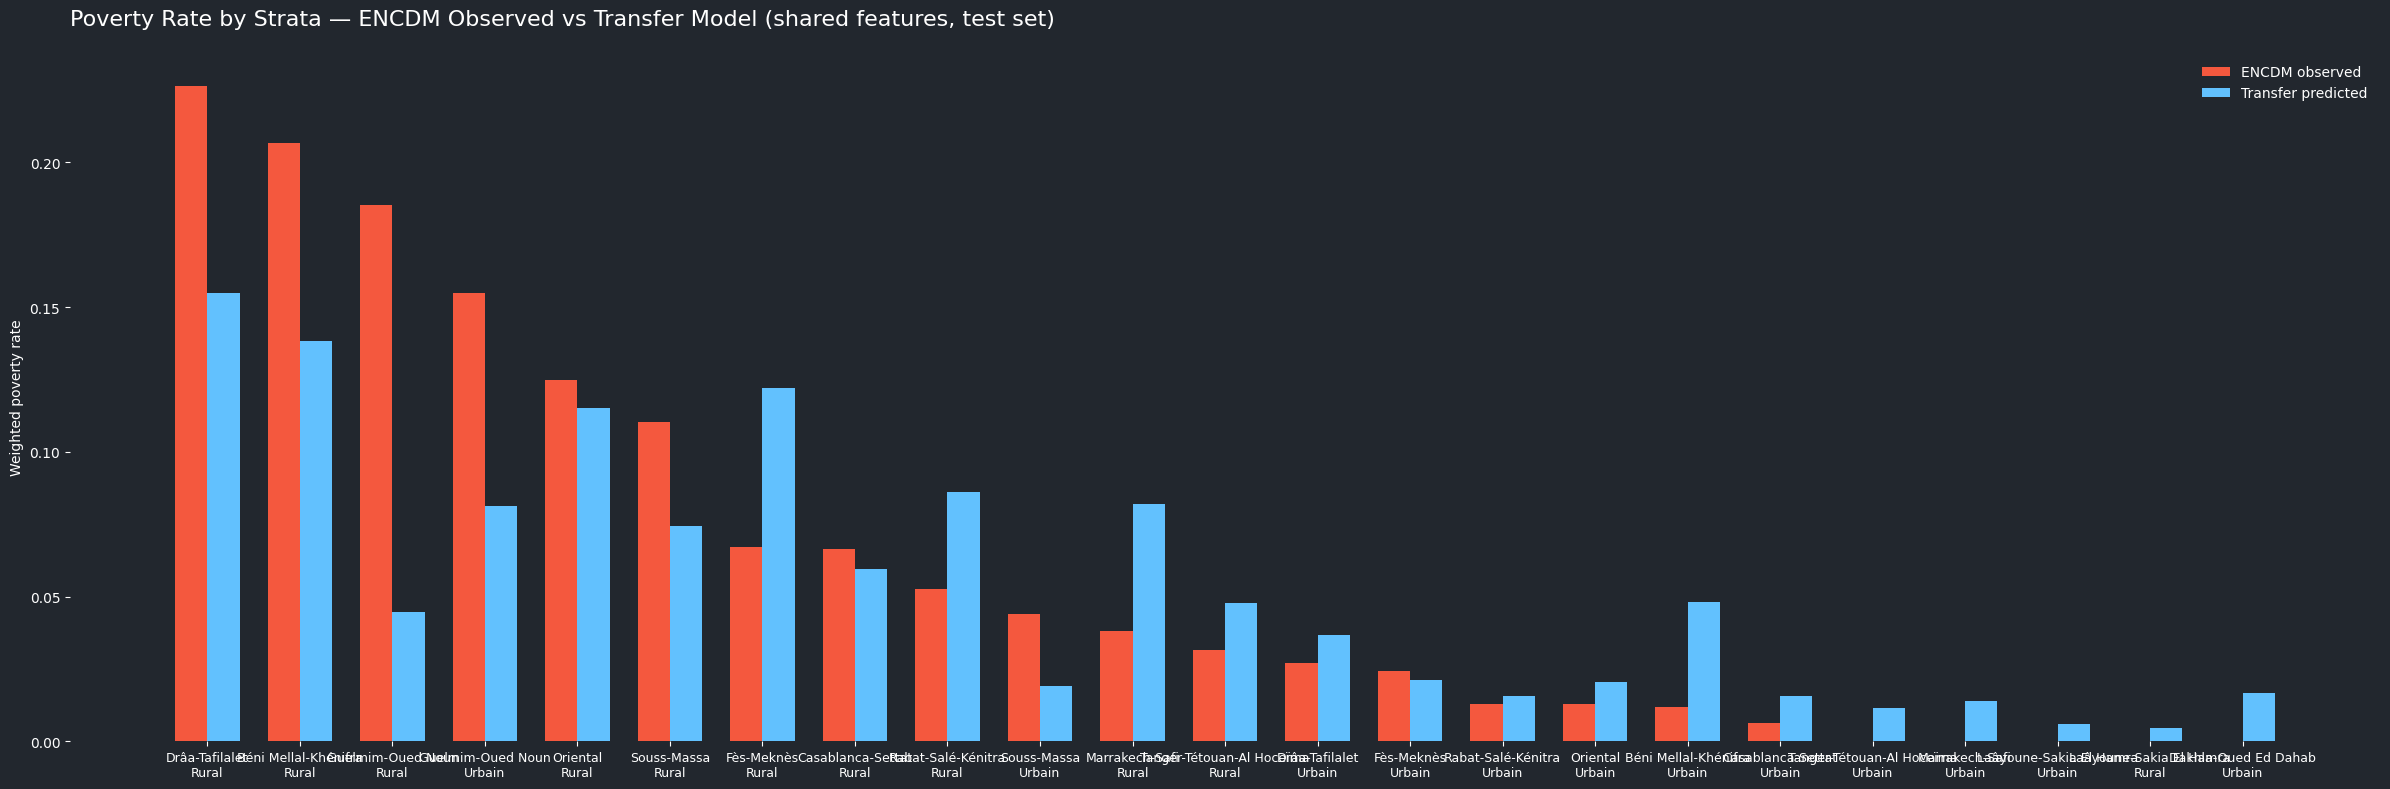

In [26]:
fig, ax = plt.subplots(figsize = (24, 8))

plotdata = StrataCompare.sort_values('poverty_rate', ascending = False)
x = np.arange(len(plotdata))
width = 0.35

ax.bar(x - width/2, plotdata['poverty_rate'], width, label = 'ENCDM observed', color = Colors['orange'])
ax.bar(x + width/2, plotdata['predicted_rate'], width, label = 'Transfer predicted', color = Colors['blue'])

ax.set_title('Poverty Rate by Strata — ENCDM Observed vs Transfer Model (shared features, test set)', loc = 'left', fontsize = 16, pad = 20)
ax.set_xticks(x)
ax.set_xticklabels([f"{r}\n{'Urbain' if m == 0 else 'Rural'}" for r, m in zip(plotdata['region'], plotdata['Milieu'])], fontsize = 9)
ax.legend(frameon = False)
ax.set_ylabel('Weighted poverty rate')

for spine in ax.spines.values() : spine.set_visible(False)
plt.tight_layout()
plt.savefig('../Assets/Plots/Poverty Rate ENCDM vs RGPH Predicted.png', dpi = 150, facecolor = '#22272E', bbox_inches = 'tight')
plt.show()

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

CardsRGPH = {c : max(MapRGPH[c].keys()) + 1 for c in RGPHConfig['categorical']}
CardsENCDM = {c : max(MapENCDM[c].keys()) + 1 for c in ENCDMConfig['categorical']}

for df, config in [(RGPH, RGPHConfig), (ENCDM, ENCDMConfig)] :
    for column in config['categorical'] :
        df[column] = df[column].fillna(0).astype(int)
    for column in config['numerical'] :
        df[column] = df[column].fillna(df[column].median()).astype('float32')
DimsRGPH = [(CardsRGPH[c], min(16, (CardsRGPH[c] + 1) // 2)) for c in RGPHConfig['categorical']]
DimsENCDM = [(CardsENCDM[c], min(16, (CardsENCDM[c] + 1) // 2)) for c in ENCDMConfig['categorical']]

ENCDM['strata_key'] = StrataKey
RGPH['strata_key'] = RGPH['REG'].astype(int).astype(str) + '_' + RGPH['MIL'].astype(int).astype(str)
EncdmByStrata = {k: ENCDM[ENCDM['strata_key'] == k].index.to_numpy() for k in ENCDM['strata_key'].unique()}

class CleanDataset(Dataset):
    def __init__(self, df, config, istarget = False):
        self.categorical = torch.tensor(df[config['categorical']].astype(int).values, dtype = torch.long)
        self.numerical = torch.tensor(df[config['numerical']].astype('float32').values)
        self.weights = torch.tensor(df[config['weight']].astype('float32').values)
        self.weights = self.weights / self.weights.mean()
        self.strata = df['strata_key'].values
        self.targets = torch.tensor(df[config['target']].astype('float32').values) if istarget else None

    def __len__(self):
        return len(self.categorical)

    def __getitem__(self, idx):
        if self.targets is not None:
            return self.categorical[idx], self.numerical[idx], self.targets[idx], self.weights[idx], self.strata[idx]
        return self.categorical[idx], self.numerical[idx], self.weights[idx], self.strata[idx]

class MultiEmbedding(nn.Module):
    def __init__(self, embspecs):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(classes, dims) for classes, dims in embspecs])
        self.totaldim = sum(dims for _, dims in embspecs)

    def forward(self, x):
        return torch.cat([emb(x[:, index]) for index, emb in enumerate(self.embeddings)], dim = -1)

class FunctionalTargetNet:
    def __init__(self, inputdim, hiddendim, outputdim):
        self.shapes = {'w1': (hiddendim, inputdim), 'b1': (hiddendim,), 'w2': (outputdim, hiddendim), 'b2': (outputdim,)}
        self.sizes = {key: torch.prod(torch.tensor(val)).item() for key, val in self.shapes.items()}
        self.totalparams = sum(self.sizes.values())

    def forward(self, features, weights):
        features = torch.bmm(features.unsqueeze(1), weights['w1'].transpose(1, 2)).squeeze(1) + weights['b1']
        features = F.relu(features)
        return torch.bmm(features.unsqueeze(1), weights['w2'].transpose(1, 2)).squeeze(1) + weights['b2']

class Hypernetwork(nn.Module):
    def __init__(self, inputdim, targetnet):
        super().__init__()
        self.targetnet = targetnet
        self.mlp = nn.Sequential(nn.Linear(inputdim, 64), nn.ReLU(), nn.Linear(64, targetnet.totalparams))

    def forward(self, features):
        batchsize = features.shape[0]
        chunks = torch.split(self.mlp(features), list(self.targetnet.sizes.values()), dim = -1)
        return {key: chunks[index].view(batchsize, shape[0], shape[1]) if len(shape) == 2 else chunks[index].view(batchsize, shape[0]) for index, (key, shape) in enumerate(self.targetnet.shapes.items())}

RgphDs = CleanDataset(RGPH, RGPHConfig, istarget = False)
EncdmTrainDs = CleanDataset(ENCDM.iloc[TrainIdx], ENCDMConfig, istarget = True)
EncdmValDs = CleanDataset(ENCDM.iloc[ValIdx], ENCDMConfig, istarget = True)

print(f'RGPH: {len(RgphDs)} | ENCDM train: {len(EncdmTrainDs)} | ENCDM val: {len(EncdmValDs)}')

RGPH: 730099 | ENCDM train: 11179 | ENCDM val: 2395


In [28]:
from torch.utils.data import DataLoader
import torch.optim as optim

Hiddendim = 32
Outputdim = len(Targets)
RgphInputdim = sum(dims for _, dims in DimsRGPH) + len(RGPHConfig['numerical'])
EncdmInputdim = sum(dims for _, dims in DimsENCDM) + len(ENCDMConfig['numerical'])

RgphLoader = DataLoader(RgphDs, batch_size = 512, shuffle = True, drop_last = True)
EncdmLoader = DataLoader(EncdmTrainDs, batch_size = 512, shuffle = True, drop_last = True)

RgphEmbedding = MultiEmbedding(DimsRGPH)
EncdmEmbedding = MultiEmbedding(DimsENCDM)
TargetNet = FunctionalTargetNet(EncdmInputdim, Hiddendim, Outputdim)
Hypernet = Hypernetwork(RgphInputdim, TargetNet)

Optimizer = optim.Adam(list(RgphEmbedding.parameters()) + list(EncdmEmbedding.parameters()) + list(Hypernet.parameters()), lr = 0.001)
Criterion = nn.BCEWithLogitsLoss(reduction = 'none')

def PairedBatch(rgphcat, rgphnum, rgphstrata):
    encidx = [np.random.choice(EncdmByStrata.get(s, next(iter(EncdmByStrata.values())))) for s in rgphstrata]
    encbatch = ENCDM.loc[encidx]
    encdmcat = torch.tensor(encbatch[ENCDMConfig['categorical']].astype(int).values, dtype = torch.long)
    encdmnum = torch.tensor(encbatch[ENCDMConfig['numerical']].astype('float32').values)
    encdmtgts = torch.tensor(encbatch[Targets].astype('float32').values)
    encdmwts = torch.tensor(encbatch[WeightCol].astype('float32').values)
    encdmwts = encdmwts / encdmwts.mean()
    return encdmcat, encdmnum, encdmtgts, encdmwts

Epochs = 12
History = []

for epoch in range(Epochs):
    Epochloss = 0.0
    Batches = 0

    for rgphcat, rgphnum, rgphwts, rgphstrata in RgphLoader:
        Optimizer.zero_grad()
        encdmcat, encdmnum, encdmtgts, encdmwts = PairedBatch(rgphcat, rgphnum, list(rgphstrata))

        rgphfeatures = torch.cat([RgphEmbedding(rgphcat), rgphnum], dim = -1)
        generatedweights = Hypernet(rgphfeatures)
        encdmfeatures = torch.cat([EncdmEmbedding(encdmcat), encdmnum], dim = -1)
        predictions = TargetNet.forward(encdmfeatures, generatedweights)

        rawloss = Criterion(predictions, encdmtgts)
        weightedloss = (rawloss * encdmwts.unsqueeze(-1)).mean()
        weightedloss.backward()
        Optimizer.step()

        Epochloss += weightedloss.item()
        Batches += 1

    History.append(Epochloss / Batches)
    print(f'Epoch {epoch + 1}/{Epochs} | Loss: {History[-1]:.4f}')

Epoch 1/12 | Loss: 0.3345
Epoch 2/12 | Loss: 0.2372
Epoch 3/12 | Loss: 0.2327
Epoch 4/12 | Loss: 0.2318
Epoch 5/12 | Loss: 0.2271
Epoch 6/12 | Loss: 0.2224
Epoch 7/12 | Loss: 0.2182
Epoch 8/12 | Loss: 0.2131
Epoch 9/12 | Loss: 0.2091
Epoch 10/12 | Loss: 0.2054
Epoch 11/12 | Loss: 0.2034
Epoch 12/12 | Loss: 0.2005


AUC      F1
val  Pauvre      0.9036  0.1186
     Vulnérable  0.8399  0.1600
test Pauvre      0.9381  0.2194
     Vulnérable  0.8366  0.1442

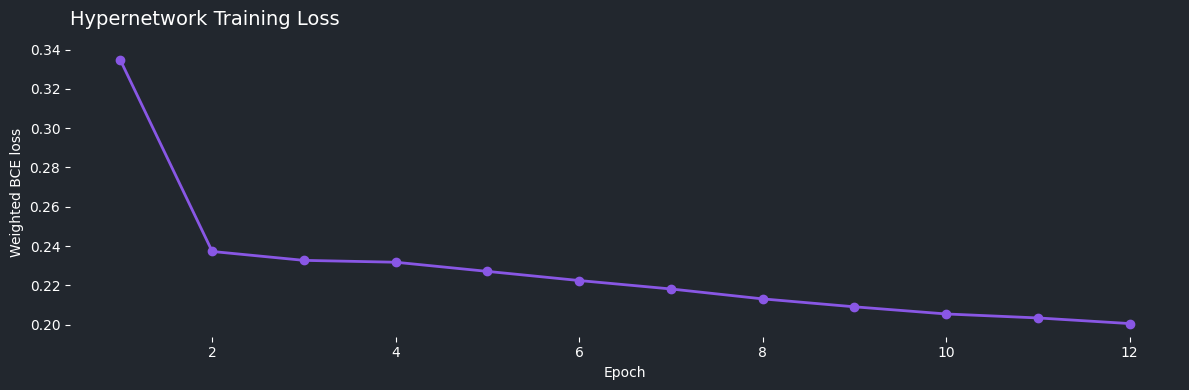

In [29]:
from sklearn.metrics import roc_auc_score, f1_score

StrataRgphMean = {}
for key in EncdmByStrata.keys() :
    subset = RGPH[RGPH['strata_key'] == key]
    if len(subset) == 0 : continue
    StrataRgphMean[key] = {
        'cat': torch.tensor(subset[RGPHConfig['categorical']].astype(int).mode().iloc[0].values, dtype = torch.long).unsqueeze(0),
        'num': torch.tensor(subset[RGPHConfig['numerical']].astype('float32').mean().values, dtype = torch.float32).unsqueeze(0)
    }

RgphEmbedding.eval()
EncdmEmbedding.eval()
Hypernet.eval()

HyperMetrics = {}

with torch.no_grad():
    for splitname, splitidx in {'val': ValIdx, 'test': TestIdx}.items() :
        HyperMetrics[splitname] = {}
        probs = {target: [] for target in Targets}
        ytrue = {target: [] for target in Targets}
        weights = []

        for i in splitidx:
            row = ENCDM.loc[i]
            key = row['strata_key']
            context = StrataRgphMean.get(key, next(iter(StrataRgphMean.values())))

            rgphfeatures = torch.cat([RgphEmbedding(context['cat']), context['num']], dim = -1)
            generatedweights = Hypernet(rgphfeatures)
            encdmcat = torch.tensor(row[ENCDMConfig['categorical']].astype(int).values, dtype = torch.long).unsqueeze(0)
            encdmnum = torch.tensor(row[ENCDMConfig['numerical']].astype('float32').values).unsqueeze(0)
            encdmfeatures = torch.cat([EncdmEmbedding(encdmcat), encdmnum], dim = -1)
            prediction = torch.sigmoid(TargetNet.forward(encdmfeatures, generatedweights)).squeeze(0).numpy()

            for index, target in enumerate(Targets) :
                probs[target].append(prediction[index])
                ytrue[target].append(int(row[target]))
            weights.append(row[WeightCol])

        weights = np.array(weights)
        for target in Targets :
            y = np.array(ytrue[target])
            p = np.array(probs[target])
            pred = (p >= Thresholds[target]).astype(int)
            HyperMetrics[splitname][target] = {
                'AUC': roc_auc_score(y, p, sample_weight = weights),
                'F1': f1_score(y, pred, sample_weight = weights, zero_division = 0)
            }

HyperTable = pd.DataFrame({(splitname, target): metrics for splitname, targets in HyperMetrics.items() for target, metrics in targets.items()}).T
display(HyperTable.round(4))

fig, ax = plt.subplots(figsize = (12, 4))
ax.plot(range(1, len(History) + 1), History, color = Colors['purple'], marker = 'o', linewidth = 2)
ax.set_title('Hypernetwork Training Loss', loc = 'left', fontsize = 14, pad = 16)
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted BCE loss')
for spine in ax.spines.values() : spine.set_visible(False)
plt.tight_layout()
plt.savefig('../Assets/Plots/Hypernetwork Training Loss.png', dpi = 150, facecolor = '#22272E', bbox_inches = 'tight')
plt.show()

In [30]:
checkpoint = {
    'rgphembedding': RgphEmbedding.state_dict(),
    'encdmembedding': EncdmEmbedding.state_dict(),
    'hypernet': Hypernet.state_dict(),
    'dimsrgph': DimsRGPH,
    'dimsencdm': DimsENCDM,
    'hiddendim': Hiddendim,
    'outputdim': Outputdim,
    'history': History,
    'thresholds': Thresholds
}

if not pathlib.Path('../Models/Classifier/Hypernet.pt').exists() :
    torch.save(checkpoint, '../Models/Classifier/Hypernet.pt')

print('Saved models:')
for file in sorted(pathlib.Path('../Models/Classifier').glob('*')) :
    print(f'  {file.name}')

Saved models:
  ENCDM_LGBM_Pauvre.joblib
  ENCDM_LGBM_Vulnérable.joblib
  Hypernet.pt
  Transfer_LGBM_Pauvre.joblib
  Transfer_LGBM_Vulnérable.joblib
